In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt

In [4]:
import seaborn as sns

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

In [6]:
print("Imports successful")

Imports successful


In [7]:
df = pd.read_csv("../data/diabetes.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [8]:
print(df.columns.tolist())

['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [10]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [11]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [12]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [13]:
print(df["Outcome"].value_counts())

print("\nPercentage:")
print(df["Outcome"].value_counts(normalize=True) * 100)

Outcome
0    500
1    268
Name: count, dtype: int64

Percentage:
Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


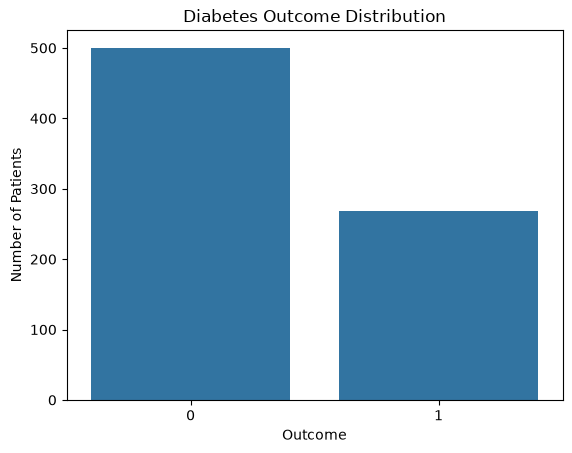

In [14]:
sns.countplot(data=df, x="Outcome")

plt.title("Diabetes Outcome Distribution")
plt.xlabel("Outcome")
plt.ylabel("Number of Patients")
plt.show()

In [15]:
zero_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

for column in zero_columns:
    print(column, ":", (df[column] == 0).sum())

Glucose : 5
BloodPressure : 35
SkinThickness : 227
Insulin : 374
BMI : 11


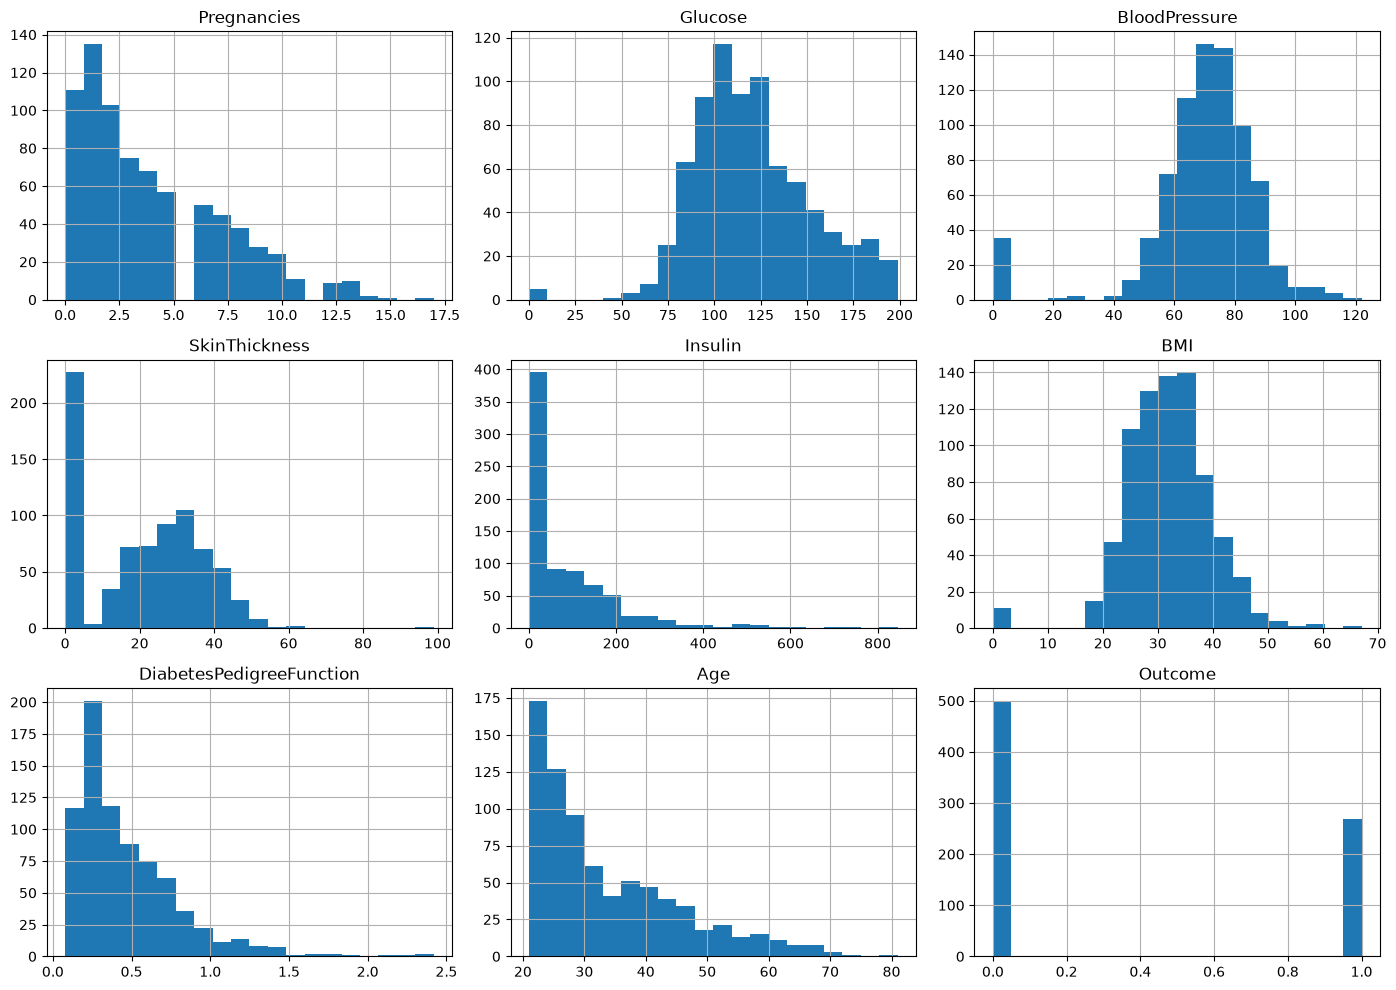

In [16]:
df.hist(figsize=(14, 10), bins=20)

plt.tight_layout()
plt.show()

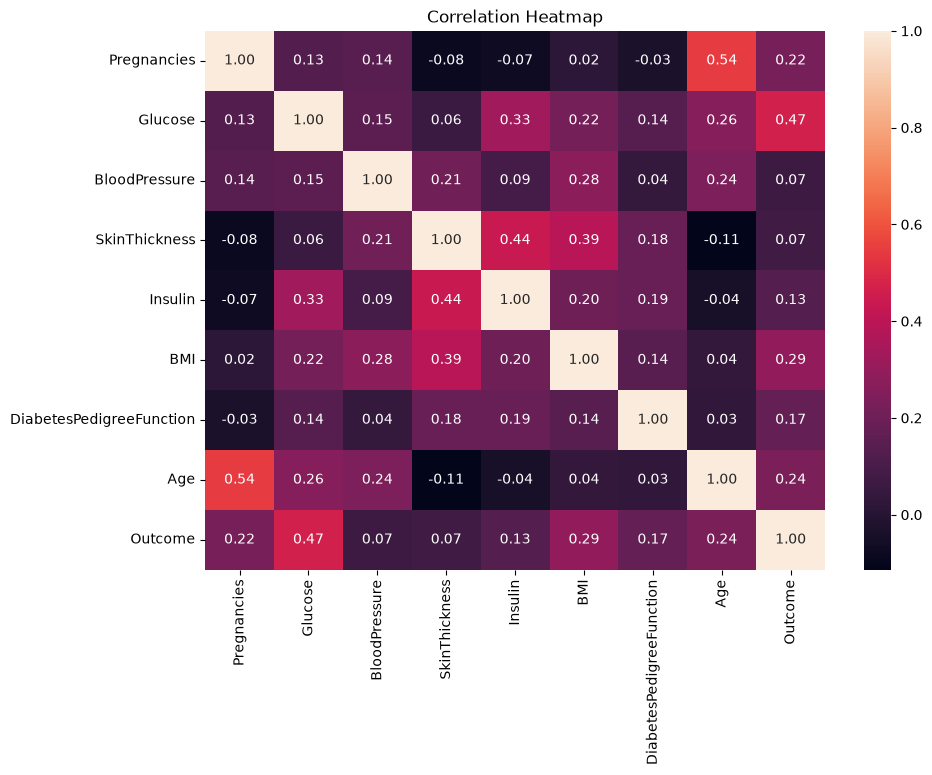

In [17]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    df.corr(),
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [18]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (768, 8)
y shape: (768,)


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 614
Testing samples: 154


In [20]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
scaler.fit_transform(X_train)
scaler.transform(X_test)

array([[ 0.96054099,  1.20788789, -0.29601471, ..., -0.58221684,
        -0.55579092,  0.56103382],
       [ 1.86648903, -1.67775979,  1.98813468, ...,  0.44897876,
        -0.58306107,  1.15306018],
       [-0.5493724 ,  0.03460257,  0.3565994 , ...,  0.499902  ,
         0.01688223, -0.6230189 ],
       ...,
       [-0.5493724 , -1.23381399, -0.94862882, ..., -0.44217793,
         3.70138246, -0.70759409],
       [ 0.05459296,  2.00064824,  0.46536842, ...,  0.6399409 ,
        -0.64669142, -0.20014293],
       [-0.85135507, -1.58262854,  0.46536842, ...,  0.15617013,
        -0.16794879, -1.04589487]], shape=(154, 8))

In [22]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)

print("Model trained successfully!")

Model trained successfully!


In [23]:
y_pred = model.predict(X_test_scaled)

print(y_pred[:20])

[1 0 0 0 0 0 0 1 0 1 0 1 0 0 0 0 1 0 1 0]


In [24]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

Accuracy : 0.7143
Precision: 0.6087
Recall   : 0.5185
F1 Score : 0.56


[[82 18]
 [26 28]]


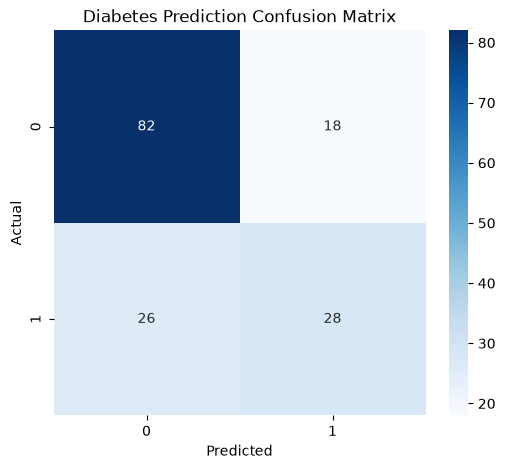

In [25]:
cm = confusion_matrix(y_test, y_pred)

print(cm)
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Diabetes Prediction Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [26]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.76      0.82      0.79       100
           1       0.61      0.52      0.56        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.71      0.71      0.71       154



In [27]:
y_probability = model.predict_proba(X_test_scaled)[:, 1]

auc = roc_auc_score(y_test, y_probability)

print("ROC-AUC:", round(auc, 4))

ROC-AUC: 0.823


In [28]:
import joblib

joblib.dump(model, "../models/diabetes_logistic_model.pkl")
joblib.dump(scaler, "../models/diabetes_scaler.pkl")

print("Model and scaler saved successfully!")

Model and scaler saved successfully!


In [29]:
loaded_model = joblib.load("../models/diabetes_logistic_model.pkl")
loaded_scaler = joblib.load("../models/diabetes_scaler.pkl")

sample = X_test.iloc[[0]]

sample_scaled = loaded_scaler.transform(sample)

prediction = loaded_model.predict(sample_scaled)[0]
probability = loaded_model.predict_proba(sample_scaled)[0][1]

print("Prediction:", prediction)
print("Probability:", round(probability * 100, 2), "%")

Prediction: 1
Probability: 61.67 %


In [30]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "KNN": KNeighborsClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

results = []

for name, clf in models.items():
    clf.fit(X_train_scaled, y_train)
    preds = clf.predict(X_test_scaled)
    probs = clf.predict_proba(X_test_scaled)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, preds), 4),
        "Precision": round(precision_score(y_test, preds), 4),
        "Recall": round(recall_score(y_test, preds), 4),
        "F1": round(f1_score(y_test, preds), 4),
        "ROC-AUC": round(roc_auc_score(y_test, probs), 4)
    })

results_df = pd.DataFrame(results).sort_values(by="ROC-AUC", ascending=False)
results_df

c:\Users\Dell\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
5,Gradient Boosting,0.7532,0.6667,0.5926,0.6275,0.8407
0,Logistic Regression,0.7143,0.6087,0.5185,0.5600,0.8230
2,Random Forest,0.7597,0.6809,0.5926,0.6337,0.8147
3,SVM,0.7532,0.6600,0.6111,0.6346,0.7924
4,KNN,0.7013,0.5833,0.5185,0.5490,0.7405
1,Decision Tree,0.7208,0.6341,0.4815,0.5474,0.6657


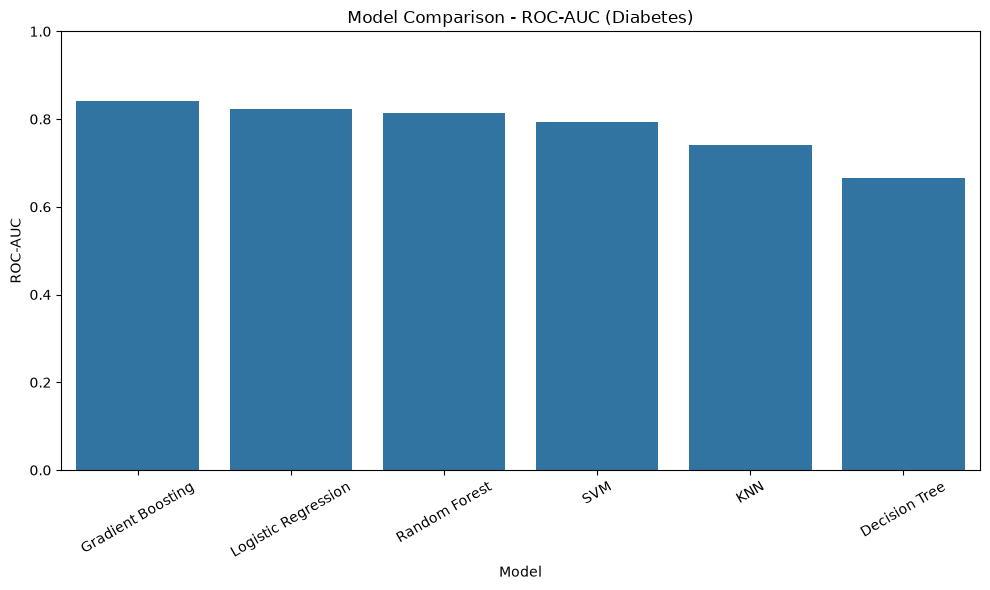

In [31]:
plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x="Model", y="ROC-AUC")
plt.title("Model Comparison - ROC-AUC (Diabetes)")
plt.xticks(rotation=30)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [32]:
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

print("Best model:", best_model_name)

joblib.dump(best_model, "../models/diabetes_best_model.pkl")
joblib.dump(scaler, "../models/diabetes_scaler.pkl")

print("Best diabetes model and scaler saved successfully!")

Best model: Gradient Boosting
Best diabetes model and scaler saved successfully!


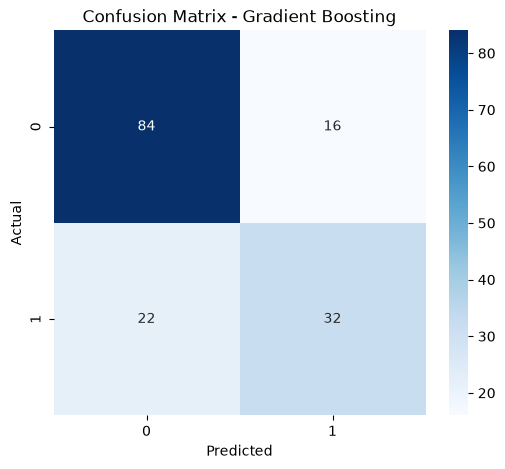

              precision    recall  f1-score   support

           0       0.79      0.84      0.82       100
           1       0.67      0.59      0.63        54

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.72       154
weighted avg       0.75      0.75      0.75       154



In [33]:
best_preds = best_model.predict(X_test_scaled)

cm = confusion_matrix(y_test, best_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(y_test, best_preds))